<div align="center">


# **FINAL PROJECT**
## **Movies Dataset**

### Data Mining  

**Source:** Hugging Face – TMDB Movies Dataset  

**Team Members**  
Juan Daniel Ramirez Mojica  
Maria Paula Carvajal Martinez  
Paula Daniela Guzman Zabala  
Karem Nataly Sierra Molina  




**University**  
Universidad Nacional de Colombia  

**Semester**  
2026-1  

</div>

---
## **1. Description of the Dataset**

### **1.1. Source and Context**

**Dataset Source:**

> [1] Datadruids, *"Full TMDB Movies Dataset"*, HuggingFace.co, 2026. Available at: https://huggingface.co/datasets/ada-datadruids/full_tmdb_movies_dataset. [Accessed: Feb. 24, 2026]

The dataset originates from **TMDB (The Movie Database)**, a collaborative film database that contains information on millions of productions worldwide.

### **1.2. Dataset Content**

The dataset comprises **1,142,342 movie records** and **24 variables** describing relevant attributes such as title, genres, popularity, budget, revenue, synopsis, and keywords.

It includes both numerical variables (`vote_count`, `revenue`, `runtime`, `popularity`) and textual variables (`overview`, `genres`, `keywords`), thereby enabling the integration of quantitative statistical analysis with Natural Language Processing (NLP) methodologies.

| Data Type | Variables | Count |
|-----------|-----------|--------|
| `int64` | id, vote_count, revenue, runtime, budget | 5 |
| `float64` | vote_average, popularity | 2 |
| `bool` | adult | 1 |
| `object` (text) | title, overview, genres, keywords, status, ... | 16 |

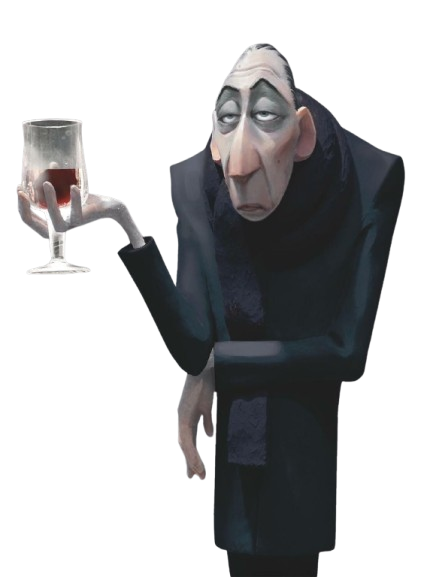

### **1.3. Objective of the Analysis**

The primary objective of this project is to develop a **content-based movie recommendation system** that operates without prior user interaction history (*cold-start scenario*).

The system is structured in two stages:

1. **Initial Filtering**: Movies are filtered by genre and minimum rating threshold in order to reduce the catalog to a subset of relevant candidates.
2. **Similarity-Based Recommendation**: Given a selected movie title, the model computes content similarity using **TF-IDF vectorization** applied to the `overview`, `genres`, and `keywords` features, in order to recommend similar movies.

> **Presentation:** https://www.canva.com/design/DAHCP12ebtc/5khUpBy5Q0LfSIDzacsflA/edit

---
## **2. Experimental Setup and Data Acquisition**

### **2.1. Installation and Library Imports**

The following commands are required only during the initial environment configuration:

In [39]:
#pip install datasets
#pip install pandas numpy matplotlib seaborn scikit-learn scipy tqdm ipykernel missingno jinja2 datasets

> **Reproducibility Note:**  
> All project dependencies are documented in the `requirements.txt` file to ensure reproducibility. The execution environment can be replicated by installing the specified packages prior to running the notebook.

In [40]:
# DATA HANDLING
import pandas as pd          # DataFrame structures, cleaning, groupby operations, joins, etc.
import numpy as np           # Numerical operations, algebra, arrays, mathematical functions


# VISUALIZATION / PLOTTING
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # More styled statistical visualizations (heatmaps, KDE, boxplots, etc.)
from pandas.plotting import parallel_coordinates  # Multivariate plots like parallel coordinates


# PREPROCESSING / MACHINE LEARNING
from sklearn.preprocessing import MinMaxScaler    # Normalization [0,1]
from sklearn.preprocessing import StandardScaler  # Z-score standardization
# (scikit-learn is used for scaling, models, metrics, etc.)


# SCIENTIFIC METHODS
import scipy                         # Advanced scientific functions (statistics, optimization, etc.)


# DATASETS
from datasets import load_dataset    # Load datasets (e.g., from HuggingFace)


# MISSING DATA VISUALIZATION
import missingno as msno   # Visualization of missing value patterns


# UTILITIES
from tqdm import tqdm       # Progress bars for long loops


# JUPYTER ENVIRONMENT
import ipykernel            # Kernel to run notebooks
import jinja2               # Template engine (used internally by Jupyter / HTML reports)

### **2.2. Dataset Loading**

The dataset is retrieved directly from Hugging Face. The `datasets` library automatically caches the downloaded files, ensuring that subsequent executions are performed instantaneously.

In [41]:
# Load the dataset from Hugging Face
dataset = load_dataset("ada-datadruids/full_tmdb_movies_dataset")

# Display the available dataset splits
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords'],
        num_rows: 1142342
    })
})


In [42]:
# Convert the "train" split to a pandas DataFrame
df = dataset["train"].to_pandas()

# Convert the selected split into a pandas DataFrame
df = dataset["train"].to_pandas()

print(f"Dataset loaded: {len(df):,} rows × {df.shape[1]} columns")

Dataset loaded: 1,142,342 rows × 24 columns


### **2.3. Initial Inspection**

The following section presents the downloaded files, the configuration of the appropriate directory path, and the subsequent data loading process.

In [43]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [44]:
df.tail()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
1142337,741864,Criadores de Melodias - As Lendas do Rock,0.0,0,Released,None,0,0,False,None,...,Criadores de Melodias - As Lendas do Rock,None,0.600,/lZtb2L6E5e0MGBe3iMBl168A8fG.jpg,None,None,None,None,None,None
1142338,741865,Aprenda Trombone Gospel Básico,0.0,0,Released,None,0,0,False,None,...,Aprenda Trombone Gospel Básico,None,0.600,None,None,None,None,None,None,None
1142339,741866,Aprenda Violão Avançado,0.0,0,Released,None,0,0,False,None,...,Aprenda Violão Avançado,None,0.600,/itp1p8Ex8gdSiCcdHfgKcZbhAWw.jpg,None,None,None,None,None,None
1142340,72865,Our Big Sister,0.0,0,Released,1964-04-22,0,0,False,None,...,Our Big Sister,None,0.841,None,None,Drama,None,Hong Kong,Cantonese,None
1142341,1397642,I WANT MY MOMMY,0.0,0,Released,2025-01-31,0,19,False,/f1RJgdrusjuOWn4DJtZq1CtCgbh.jpg,...,I WANT MY MOMMY,"Mourning the death of his mother, a man is pre...",0.600,/uiZePWWCYmwSsydMzZe6OEpva1O.jpg,Mommy Loves You... No Matter What,"Drama, Comedy",Four Eyes Films,United States of America,English,None


---
## **3. Exploratory Data Analysis (EDA)**

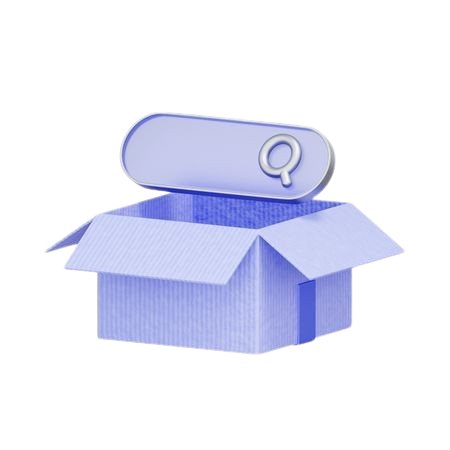

### **3.1. Dataset Quality and Structure**

**Dimensions:**

In [45]:
rows, columns = df.shape
print(f"Rows    : {rows:>10,}")
print(f"Columns : {columns:>10}")

Rows    :  1,142,342
Columns :         24


**Variable Types:**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1142342 entries, 0 to 1142341
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1142342 non-null  int64  
 1   title                 1142329 non-null  object 
 2   vote_average          1142342 non-null  float64
 3   vote_count            1142342 non-null  int64  
 4   status                1142342 non-null  object 
 5   release_date          953051 non-null   object 
 6   revenue               1142342 non-null  int64  
 7   runtime               1142342 non-null  int64  
 8   adult                 1142342 non-null  bool   
 9   backdrop_path         302739 non-null   object 
 10  budget                1142342 non-null  int64  
 11  homepage              120868 non-null   object 
 12  imdb_id               604127 non-null   object 
 13  original_language     1142342 non-null  object 
 14  original_title        1142329 non-

The dataset comprises **5 integer variables**, **2 floating-point variables**, **1 boolean variable**, and **16 object-type variables** (textual data).

Text-based columns require Natural Language Processing (NLP) preprocessing prior to model development.

**Missing Values by Column:** — sorted in descending order:

In [47]:
# Count and percentage of missing values, sorted in descending order
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "% of Total": missing_pct
}).query("`Missing Values` > 0").sort_values("Missing Values", ascending=False)

display(missing_summary)

,Missing Values,% of Total
homepage,1021474,89.4
tagline,982211,86.0
backdrop_path,839603,73.5
keywords,833525,73.0
production_companies,627504,54.9
imdb_id,538215,47.1
production_countries,507248,44.4
spoken_languages,487820,42.7
genres,458710,40.2
poster_path,361629,31.7


The columns most critical for the recommendation system exhibit a high proportion of missing values within the complete dataset:

| Column | Approx. Missing | % |
|---------|----------------|---|
| `keywords` | ~833K | 73% |
| `homepage` | ~1,017K | 89% |
| `tagline` | ~982K | 86% |
| `genres` | ~459K | 40% |
| `overview` | ~232K | 20% |

#### Missing Value Pattern

The numerical count indicates *how many* missing values are present; however, it does not reveal whether a structural pattern exists. To assess whether missingness is random (MCAR) or systematic (MAR/MNAR), the `missingno` library is employed for visualization purposes.

/tmp/ipykernel_304/1527228462.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


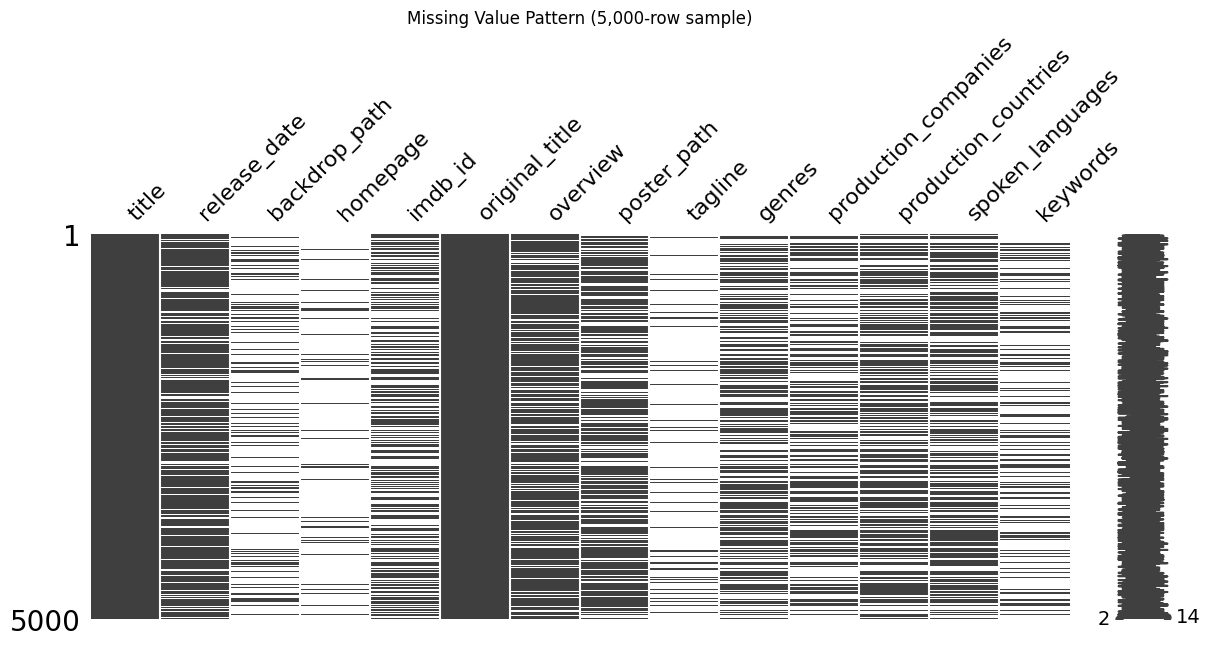

In [48]:
import missingno as msno

# Select only columns containing at least one missing value
columns_with_missing = df.columns[df.isnull().any()].tolist()

msno.matrix(
    df[columns_with_missing].sample(5000, random_state=42),
    figsize=(14, 5)
)

plt.title("Missing Value Pattern (5,000-row sample)")
plt.tight_layout()
plt.show()

**How to Interpret This Matrix**

- **Gray lines** indicate present values, whereas **white lines** represent missing values.
- If white gaps are concentrated in the same rows across multiple columns, this suggests a **MAR/MNAR pattern** (i.e., incomplete records tend to be missing multiple fields simultaneously).
- This observation justifies **removing** such rows rather than imputing them: if a movie lacks both `overview` and `genres`, it is also likely to lack other informative variables relevant for recommendation.

### **3.2. Univariate Statistics**

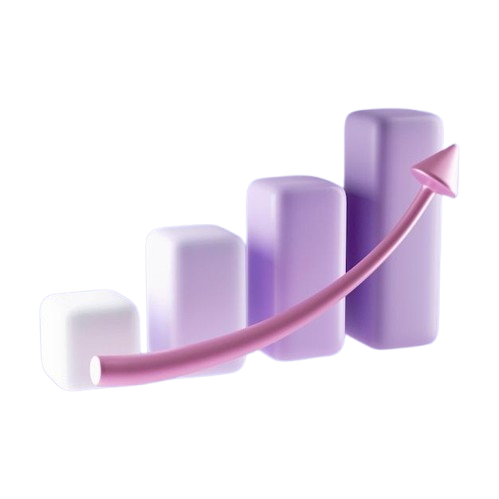

The main measures of central tendency and dispersion are computed to characterize the numerical variables:

| Measure | Description | Purpose |
|----------|-------------|----------|
| **Mean** | Arithmetic average | Represents the overall typical value |
| **Median** | Central value (50th percentile) | Robust to outliers |
| **Standard Deviation** | Dispersion around the mean | Assesses variability |
| **Min / Max** | Extreme values | Identifies the observed range and potential anomalies |

In [49]:
df.describe().T  # .T transposes the table to display statistics by variable rather than by metric

,count,mean,std,min,25%,50%,75%,max
id,1142342.0,743886.594286,3.975214e+05,2.0,412592.25,748970.5,1097094.750,1.397836e+06
vote_average,1142342.0,1.871655,3.017612e+00,0.0,0.00,0.0,4.700,1.000000e+01
vote_count,1142342.0,18.776422,3.177172e+02,0.0,0.00,0.0,1.000,3.449500e+04
revenue,1142342.0,688689.482194,1.790831e+07,-12.0,0.00,0.0,0.000,3.000000e+09
runtime,1142342.0,47.661123,6.165081e+01,-28.0,0.00,22.0,89.000,1.440000e+04
budget,1142342.0,267266.149376,5.062581e+06,0.0,0.00,0.0,0.000,1.000000e+09
popularity,1142342.0,1.231351,7.568423e+00,0.0,0.60,0.6,0.876,2.994357e+03


**What can be inferred from the computed summary statistics?**


#### Interpretation of the Statistical Summary

- **`vote_average`**: The mean is 1.87 and the median is 0, indicating that more than 50% of the movies have no recorded rating. Among movies with votes, ratings tend to concentrate between 5 and 8.
  
- **`vote_count`**: The mean is approximately 19, while the median is 0. This suggests a **power-law distribution**, where a small number of blockbuster movies accumulate the majority of votes.
  
- **`revenue` / `budget`**: Both variables exhibit a median of 0. These zeros likely represent *missing values encoded as zeros* rather than true zero revenue or budget. Consequently, these columns cannot be reliably used without prior transformation or cleaning.
  
- **`runtime`**: The mean is approximately 51 minutes, whereas the median is around 74 minutes. This discrepancy indicates that numerous zero values pull the mean downward. Additionally, extreme outliers (e.g., runtimes of several thousand minutes) suggest potential data entry errors.

In [50]:
NUMERICAL_VARIABLES = ["vote_average","vote_count","revenue","runtime","budget","popularity"]

summary = df[NUMERICAL_VARIABLES].agg(["mean", "median", "std", "min", "max"]).T

summary.columns = ["Mean","Median","Standard Deviation","Minimum","Maximum"]

summary.style.background_gradient(cmap="Blues").format("{:,.2f}")

,Mean,Median,Standard Deviation,Minimum,Maximum
vote_average,1.87,0.00,3.02,0.00,10.00
vote_count,18.78,0.00,317.72,0.00,"34,495.00"
revenue,"688,689.48",0.00,"17,908,310.80",-12.00,"3,000,000,000.00"
runtime,47.66,22.00,61.65,-28.00,"14,400.00"
budget,"267,266.15",0.00,"5,062,581.18",0.00,"999,999,999.00"
popularity,1.23,0.60,7.57,0.00,"2,994.36"


A heatmap was employed to provide an intuitive visualization of the principal descriptive statistics of the numerical variables.
Color intensity represents the magnitude of each metric, facilitating the rapid identification of differences in dispersion, value ranges, and overall trends across the analyzed variables.

From the heatmap, it can be observed that variables such as `revenue`, `budget`, `vote_count`, and `popularity` exhibit high dispersion and extremely wide value ranges. This suggests strongly right-skewed distributions and the presence of significant outliers.

This observation is further supported by the fact that their medians and lower quartiles are equal to zero, while their means are considerably higher. Such discrepancies indicate that a small number of extreme values exert a substantial influence on the measures of central tendency.

### **3.3. Multivariate Statistics**

The relationships between pairs of numerical variables are examined through covariance and Pearson correlation analysis:

In [51]:
# Numerical variables selected for multivariate analysis
NUMERICAL_VARIABLES = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]

def covariance_matrix(df, columns):
    return df[columns].cov().round(2)

def correlation_matrix(df, columns, method="pearson"):
    return df[columns].corr(method=method).round(2)

covariance = covariance_matrix(df, NUMERICAL_VARIABLES)
correlation = correlation_matrix(df, NUMERICAL_VARIABLES)

print("COVARIANCE MATRIX")
display(covariance)

print("\nCORRELATION MATRIX (Pearson)")
display(correlation)

print("\nCORRELATION MATRIX\n")
correlation

COVARIANCE MATRIX


,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,9.11,9.308000e+01,3.080976e+06,42.59,1.051456e+06,2.72
vote_count,93.08,1.009442e+05,3.949708e+09,1173.62,9.117200e+08,610.95
revenue,3080976.17,3.949708e+09,3.207076e+14,45824727.51,5.807766e+13,30603104.54
runtime,42.59,1.173620e+03,4.582473e+07,3800.82,1.685748e+07,32.83
budget,1051455.68,9.117200e+08,5.807766e+13,16857482.83,2.562973e+13,9145858.30
popularity,2.72,6.109500e+02,3.060310e+07,32.83,9.145858e+06,57.28



CORRELATION MATRIX (Pearson)


,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00



CORRELATION MATRIX



,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00


In [52]:
print("\nMATRIZ DE CORRELACIÓN \n")
correlation


MATRIZ DE CORRELACIÓN 



,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00


**Most Relevant Correlations:**

- `revenue` ↔ `vote_count` (~0.69): Movies with wider distribution tend to generate higher revenue and accumulate a larger number of votes.
  
- `budget` ↔ `revenue` (~0.64): Higher production investment is generally associated with higher financial return, although substantial dispersion remains.
  
- `vote_average` ↔ all other variables: Correlations are notably weak (maximum ~0.23). This suggests that **perceived quality is largely independent of commercial success**. A movie may receive high ratings without achieving strong box office performance.

> **Note:** Pearson correlation is sensitive to outliers. Given the highly skewed distributions observed, **Spearman’s rank correlation** provides a more robust alternative:
> `correlation_matrix(df, NUMERICAL_VARIABLES, method="spearman")`

#### Correlation Heatmap

A matrix-based visualization is employed to facilitate rapid identification of pairwise relationships:

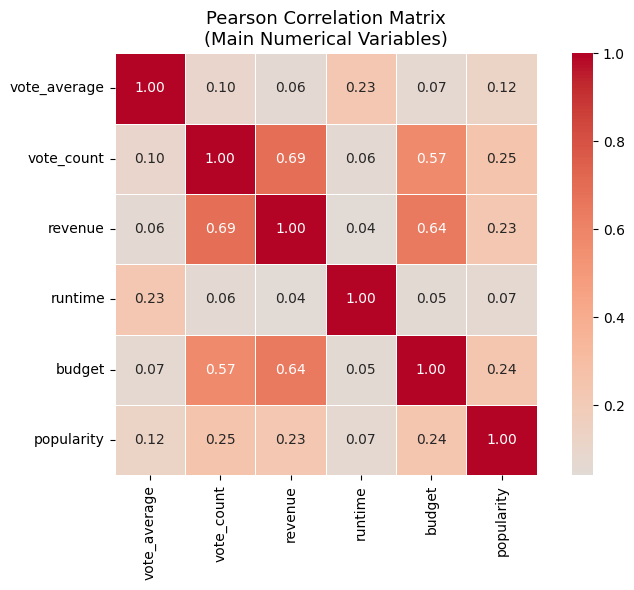

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "Pearson Correlation Matrix\n(Main Numerical Variables)",
    fontsize=13
)

plt.tight_layout()
plt.show()

**Heatmap Interpretation:**

- **Deep red** → strong positive correlation (close to +1)  
- **Deep blue** → strong negative correlation (close to −1)  
- **White** → no linear correlation  

The correlations most relevant to the recommendation objective are:

- `revenue` ↔ `vote_count`: the strongest association (~0.69), indicating that more popular movies tend to generate higher revenue.  
- `budget` ↔ `revenue`: higher production investment is generally associated with greater revenue (~0.64).  
- `vote_average` ↔ other variables: weak correlations across all comparisons, reinforcing that **perceived quality is largely independent of commercial success**.

### **3.4. Visualizations**

#### **3.4.1. Histograms**

Histograms are first generated without filtering in order to illustrate the impact of the large concentration of zero values:

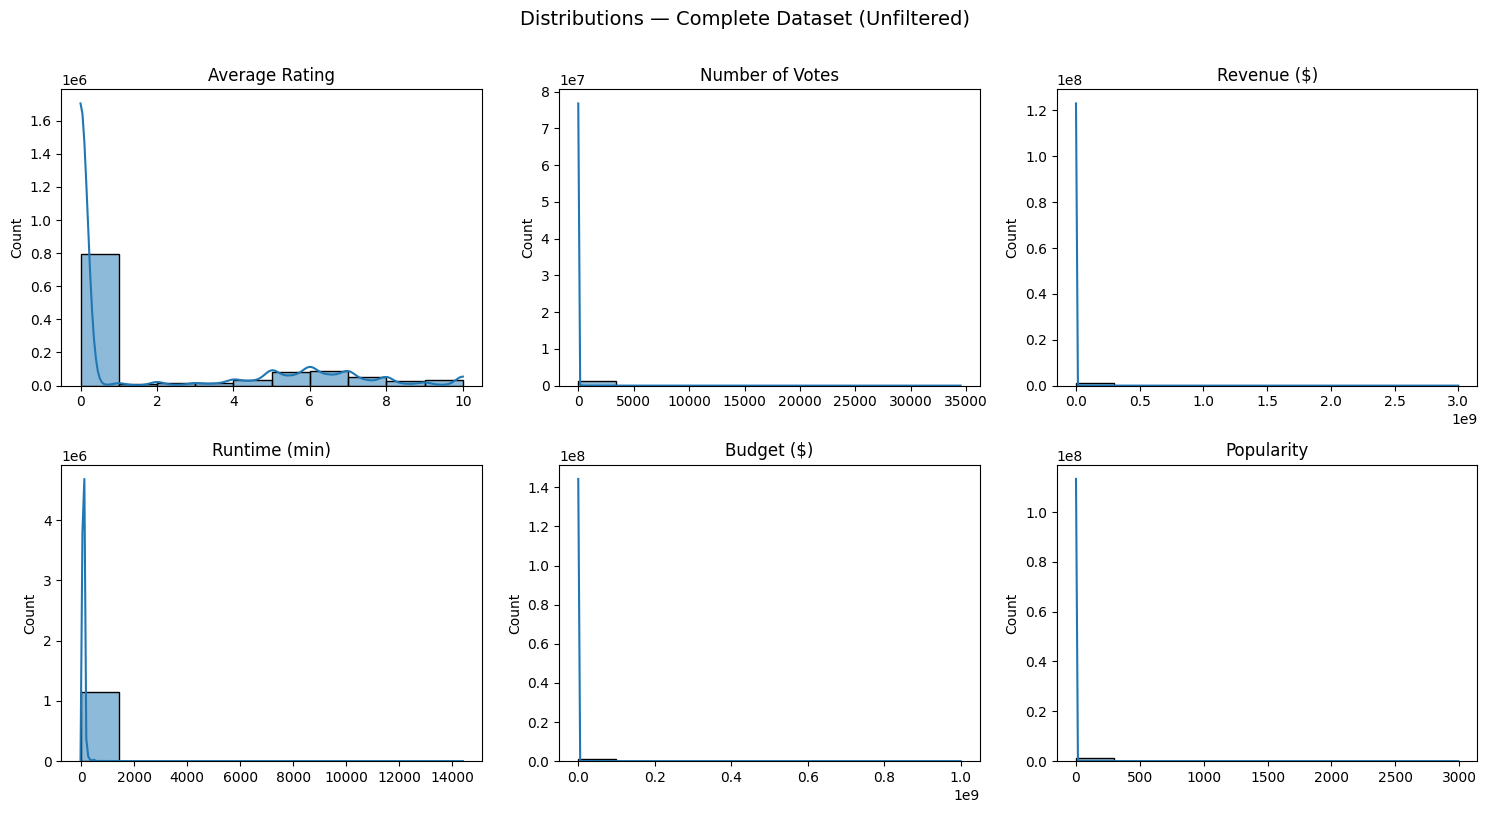

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

HIST_VARIABLES = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]

LABELS = [
    "Average Rating",
    "Number of Votes",
    "Revenue ($)",
    "Runtime (min)",
    "Budget ($)",
    "Popularity"
]

for ax, var, label in zip(axes, HIST_VARIABLES, LABELS):
    sns.histplot(df[var], kde=True, bins=10, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")

fig.suptitle(
    "Distributions — Complete Dataset (Unfiltered)",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

**Observed Issue:**

All variables display a dominant bar at zero, which compresses the remainder of the distribution. This phenomenon occurs because the majority of movies lack recorded financial data or vote counts.

In the case of `runtime`, extreme outliers of up to 14,400 minutes (~10 days) are observed, which clearly indicate data entry errors.

Therefore, data filtering and preprocessing are necessary prior to conducting meaningful statistical analysis.

Movies with complete data: 10,362 out of 1,142,342 (0.9%)


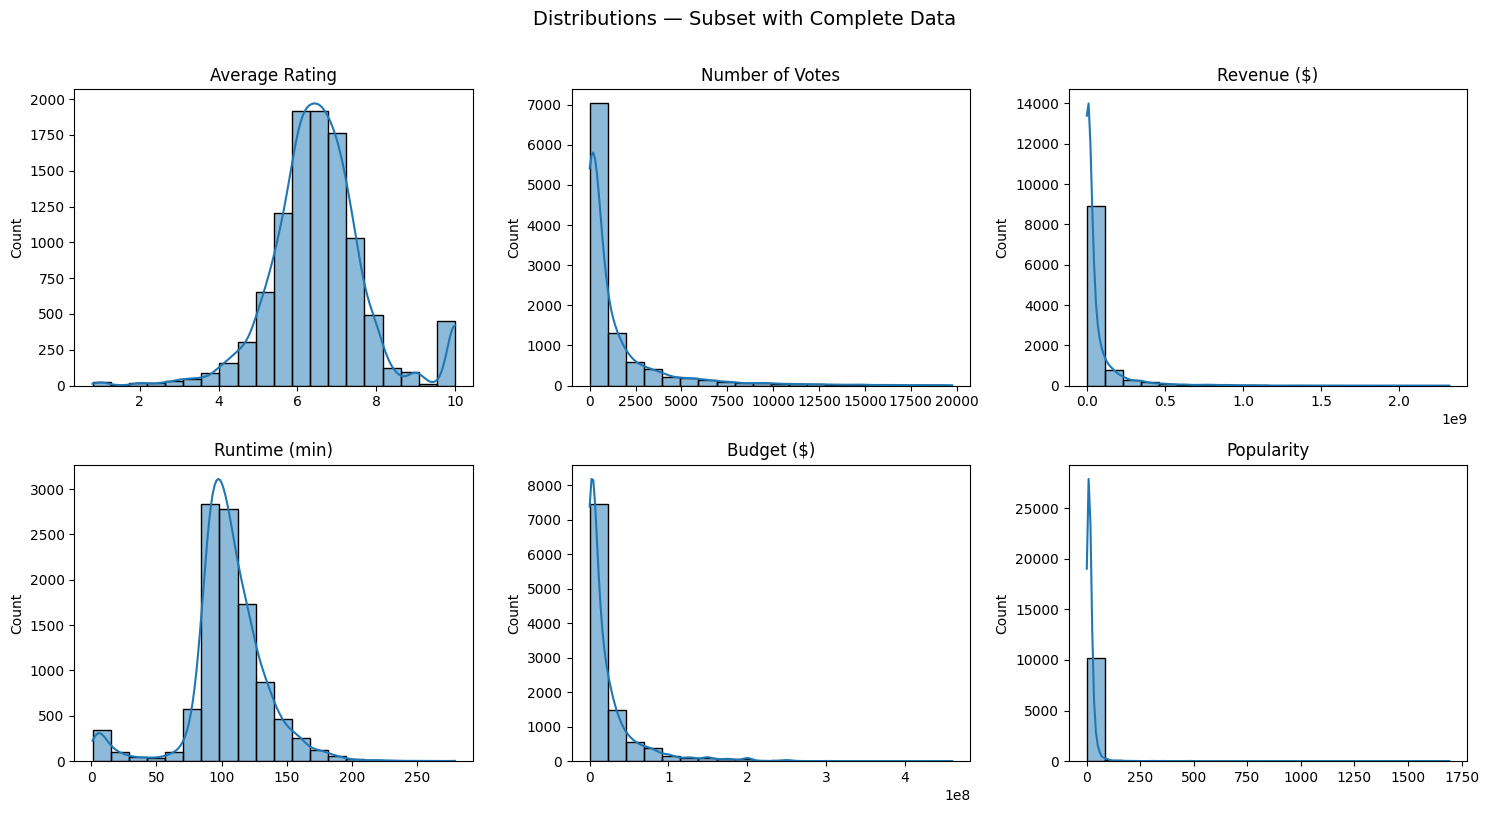

In [55]:
df_viz = df[
    (df["vote_average"] > 0) &
    (df["vote_count"].between(1, 20_000)) &
    (df["revenue"] > 0) &
    (df["runtime"].between(1, 300)) &
    (df["budget"] > 0) &
    (df["popularity"].between(0.001, 2_000))
].copy()

print(
    f"Movies with complete data: {len(df_viz):,} "
    f"out of {len(df):,} ({len(df_viz)/len(df)*100:.1f}%)"
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var, label in zip(axes, HIST_VARIABLES, LABELS):
    sns.histplot(df_viz[var], kde=True, bins=20, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")

fig.suptitle(
    "Distributions — Subset with Complete Data",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

With complete data, the underlying distributions become more clearly observable:

- **`vote_average`**: Approximately normal, concentrated between 5 and 8.
- **`vote_count`, `popularity`, `revenue`, `budget`**: Right-skewed distributions following a **power-law behavior**, where a small number of movies concentrate most of the attention and investment. This pattern is **structural in cultural consumption markets**, rather than noise.
- **`runtime`**: Concentrated between 80 and 120 minutes, corresponding to the typical range of commercial feature-length films.

The histograms of the resulting filtered subset reveal the following patterns:

- **Average Rating** — A distribution concentrated between 5 and 8 is expected, which is typical for movies with a sufficient number of votes to stabilize their ratings.
- **Number of Votes** — Strong right-skewness: most movies receive few votes, while only a limited number accumulate thousands.
- **Revenue** — Extreme right-skewness, with the majority of movies generating low revenue and a small group of blockbusters concentrating the highest values.
- **Runtime** — Concentration between 80 and 120 minutes, consistent with the standard duration of commercial feature films.
- **Budget** — Similar to revenue, exhibiting strong right-skewness and a small subset of titles with exceptionally high production budgets.
- **Popularity** — Power-law–like distribution: most movies exhibit low popularity, whereas only a few titles achieve very high visibility.

#### **3.4.3. Categorical Variables**

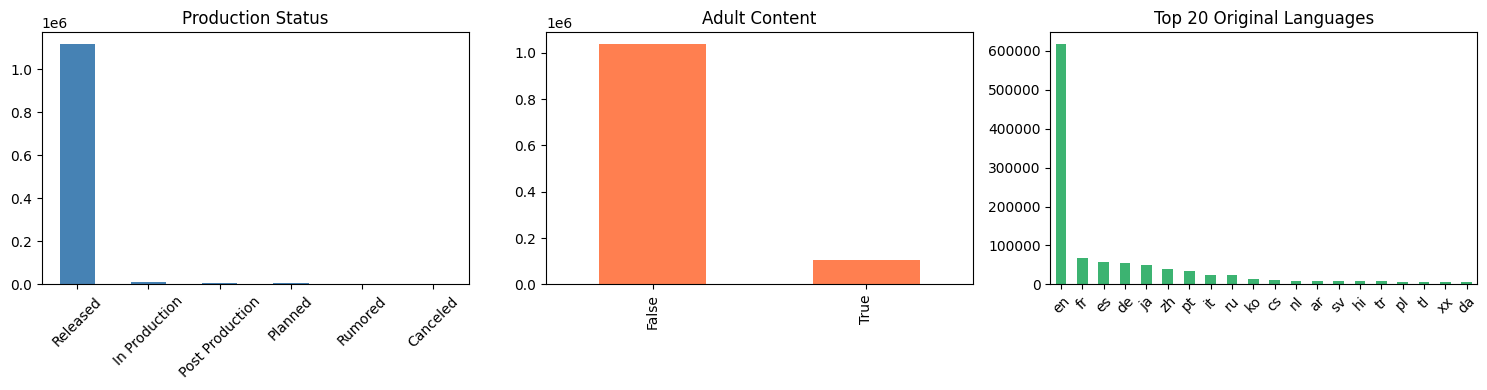

In [56]:
# ── Categorical variables — one subplot per variable ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Status
df["status"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Production Status")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Adult
df["adult"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[1], color="coral"
)
axes[1].set_title("Adult Content")
axes[1].set_xlabel("")

# Top 20 languages
df["original_language"].value_counts().head(20).plot(
    kind="bar", ax=axes[2], color="mediumseagreen"
)
axes[2].set_title("Top 20 Original Languages")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

- **`status`**: Approximately 97% of the movies are labeled as `'Released'`, indicating near-zero variance. This variable does not provide discriminative information and is therefore removed during preprocessing.

- **`adult`**: Overwhelmingly `False`, resulting in a highly imbalanced distribution.

- **`original_language`**: Dominated by English (`en`), followed by several European and Asian languages.

#### **3.4.4. Kernel Density Estimation (KDE)**

The KDE plots provide a continuous approximation of each distribution, complementing the histogram-based analysis.

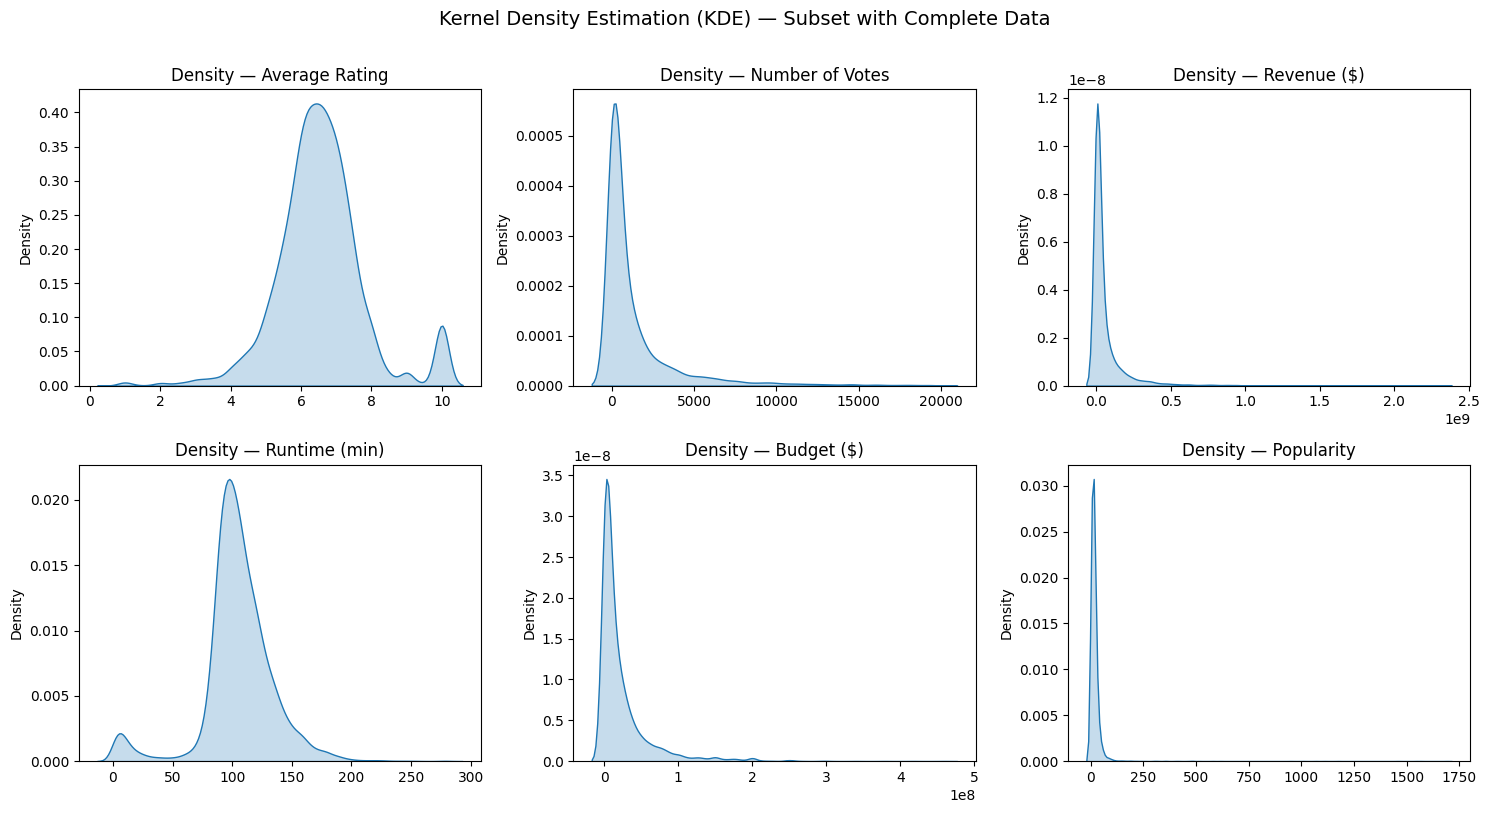

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var, label in zip(axes, HIST_VARIABLES, LABELS):
    sns.kdeplot(df_viz[var], fill=True, ax=ax)
    ax.set_title(f"Density — {label}")
    ax.set_xlabel("")

fig.suptitle(
    "Kernel Density Estimation (KDE) — Subset with Complete Data",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

Among the variables, `vote_average` and `runtime` are the closest to a normal distribution. The remaining variables exhibit pronounced right-skewness with heavy tails, confirming the presence of long-tailed behavior.

Therefore, logarithmic transformation (e.g., `np.log1p`) is required prior to their use in distance-based models, in order to reduce skewness and stabilize variance.

#### **3.4.5. Boxplots**

To ensure comparability across variables with different magnitudes and units, Z-score standardization is applied using `StandardScaler`.

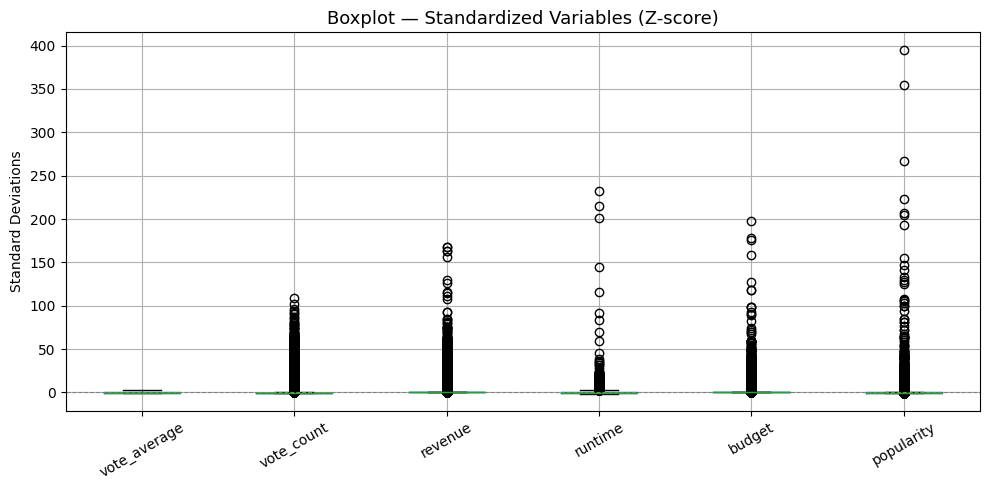

In [58]:
# Standardization using Z-score normalization
scaler_std = StandardScaler()

df_scaled = pd.DataFrame(
    scaler_std.fit_transform(df[NUMERICAL_VARIABLES]),
    columns=NUMERICAL_VARIABLES
)

fig, ax = plt.subplots(figsize=(10, 5))

df_scaled.boxplot(ax=ax)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

ax.set_title(
    "Boxplot — Standardized Variables (Z-score)",
    fontsize=13
)
ax.set_ylabel("Standard Deviations")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Financial variables and `popularity` exhibit substantial upper outliers. These values do not represent measurement errors; rather, they correspond to blockbuster productions that concentrate a large portion of industry revenue and attention.

Removing these observations would introduce bias by disproportionately favoring independent or low-budget productions. Therefore, they are retained in the dataset.

#### **3.4.6. Scatter Plots**

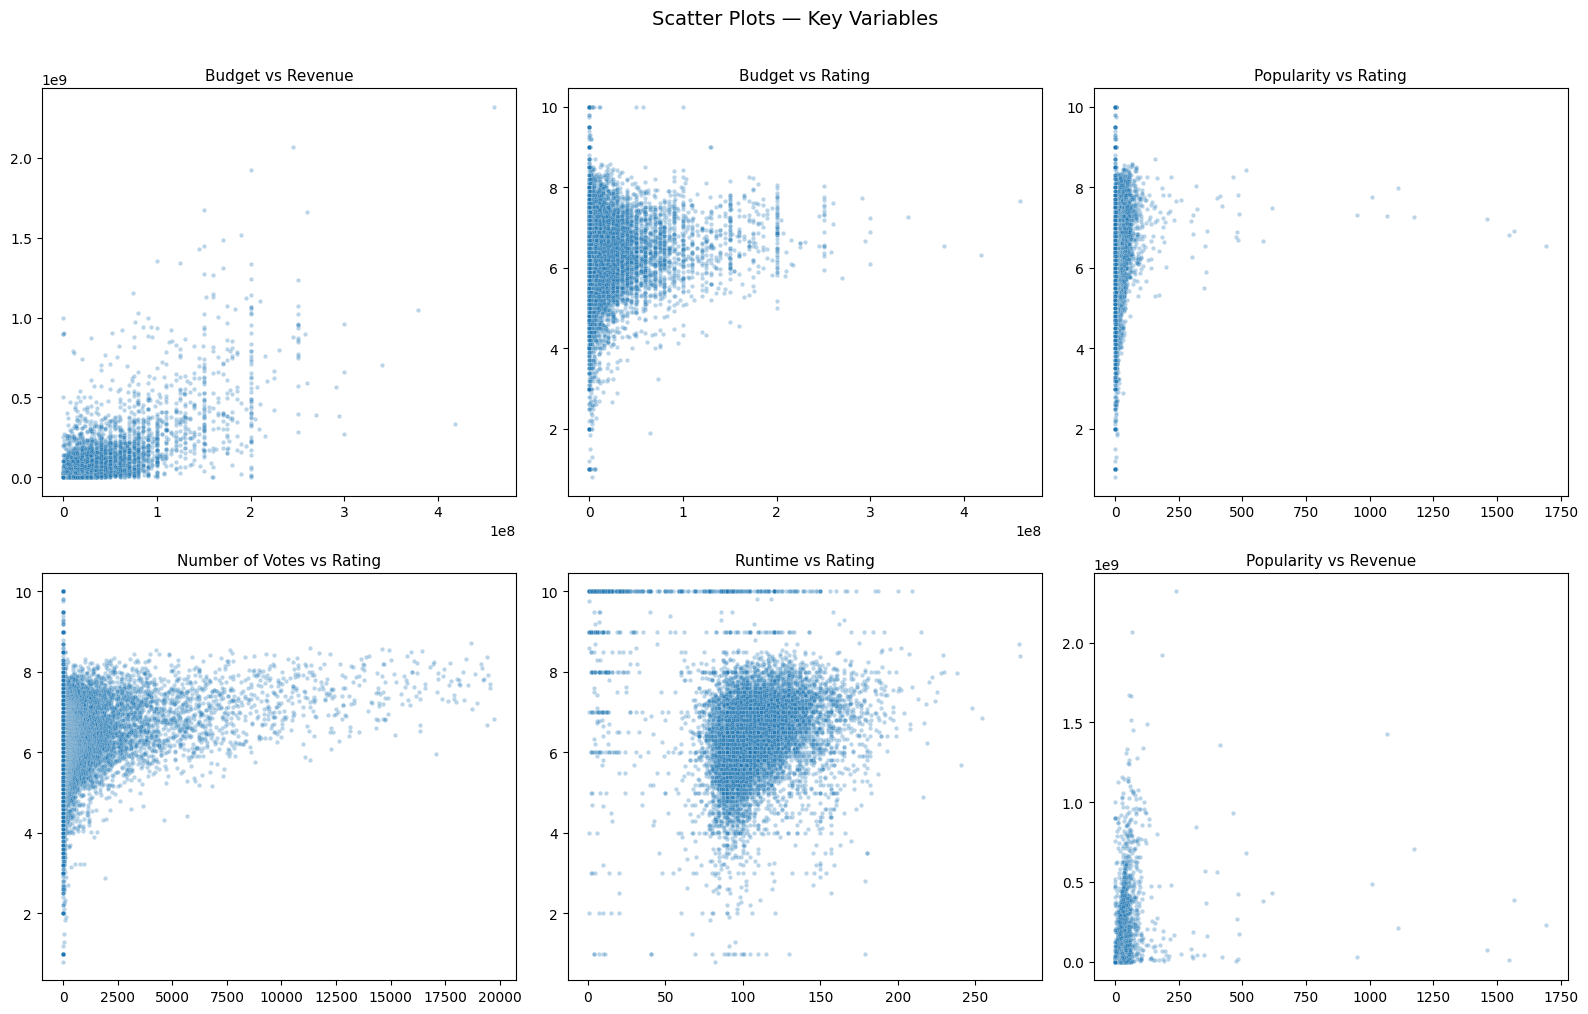

In [59]:
pairs = [
    ("budget",     "revenue",      "Budget vs Revenue"),
    ("budget",     "vote_average", "Budget vs Rating"),
    ("popularity", "vote_average", "Popularity vs Rating"),
    ("vote_count", "vote_average", "Number of Votes vs Rating"),
    ("runtime",    "vote_average", "Runtime vs Rating"),
    ("popularity", "revenue",      "Popularity vs Revenue"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (x, y, title) in zip(axes, pairs):
    sns.scatterplot(
        data=df_viz,
        x=x,
        y=y,
        alpha=0.3,
        s=10,
        ax=ax
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(
    "Scatter Plots — Key Variables",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

The observed relationships are consistent with the previously computed correlation matrix:

- **Budget → Revenue**: A positive trend is evident, albeit with substantial dispersion. Budget appears to be a necessary but not sufficient condition for commercial success.

- **Budget / Popularity → Rating**: No clear relationship is observed. High-budget or highly popular movies are not necessarily better rated.

- **Number of Votes → Rating**: As the number of votes increases, ratings tend to stabilize toward the mean. This reflects a regression-to-the-mean effect driven by larger sample sizes.

#### **3.4.7. Radar Chart (Multivariate Comparison)**

This visualization compares the numerical profiles of six movies with complete data. All axes are normalized to the [0, 1] range to ensure comparability across variables.

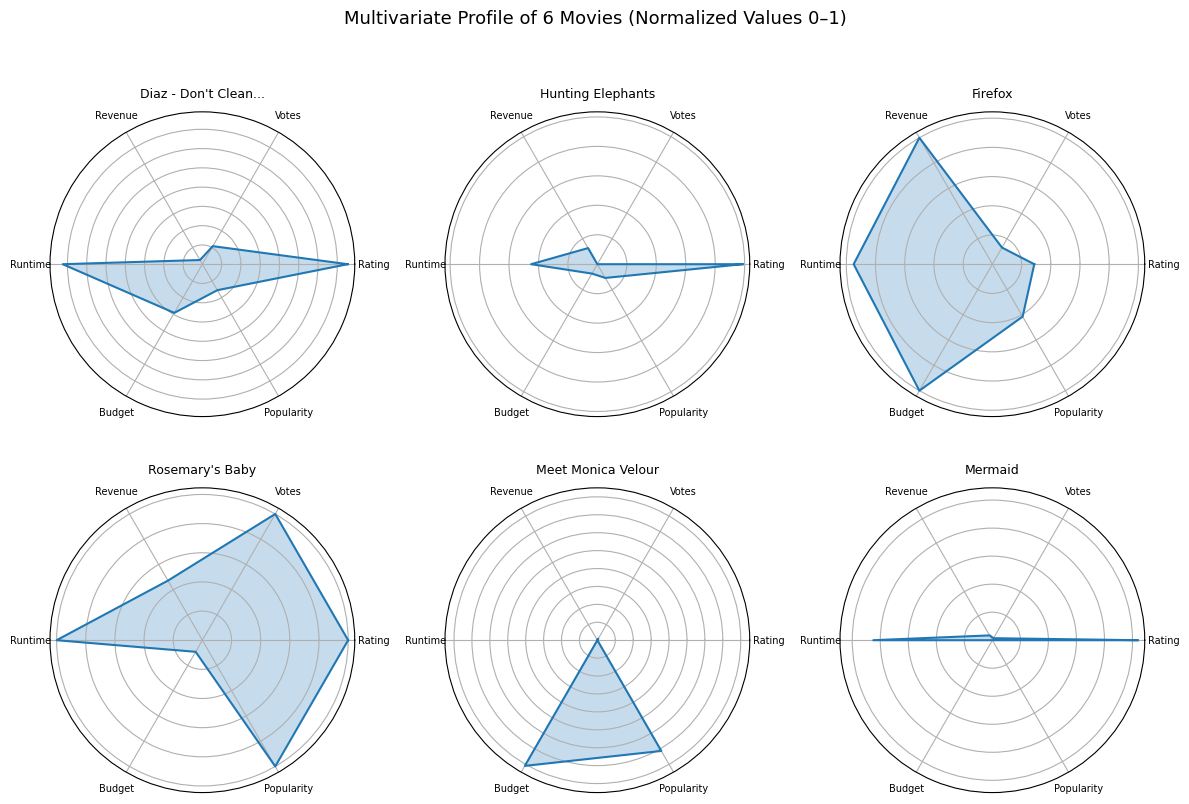

In [60]:
# ── Radar chart for 6 movies with complete data ─────────────────────────
np.random.seed(42)  # reproducibility
sample_df = df_viz.sample(n=6)

RADAR_VARIABLES = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]

RADAR_LABELS = [
    "Rating",
    "Votes",
    "Revenue",
    "Runtime",
    "Budget",
    "Popularity"
]

scaler_mm = MinMaxScaler()
scaled_values = scaler_mm.fit_transform(sample_df[RADAR_VARIABLES])

titles = [
    f"{t[:18]}..." if len(t) > 18 else t
    for t in sample_df["title"]
]

num_vars = len(RADAR_VARIABLES)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(
    2, 3,
    subplot_kw=dict(polar=True),
    figsize=(12, 8)
)

axes = axes.flatten()

for i, ax in enumerate(axes):
    values = scaled_values[i].tolist() + [scaled_values[i][0]]
    ax.plot(angles, values, linewidth=1.5)
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(titles[i], size=9, pad=10)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=7)
    ax.set_yticklabels([])

fig.suptitle(
    "Multivariate Profile of 6 Movies (Normalized Values 0–1)",
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()

**How to Interpret Each Polygon**

- **Large area** → Blockbuster-like profile (high values across multiple dimensions).
- **Small area** → Niche or independent production.
- **Asymmetric shape** → High values in some dimensions and low in others.  

For example, a movie with high `vote_average` but low `popularity` represents a *“hidden gem”* — highly rated by those who have seen it, yet relatively unknown to the broader audience. This type of insight aligns directly with the objective of the recommendation system.

### **3.5. EDA Conclusions**

The exploratory analysis reveals four structural patterns within the dataset:

1. **High Incompleteness**: Financial variables (`budget`, `revenue`) and key textual variables (`keywords`, `genres`, `overview`) exhibit between 20% and 89% missing values. Data preprocessing is therefore essential.

2. **Power-Law Distributions**: `vote_count`, `popularity`, `revenue`, and `budget` follow power-law–like distributions. The observed outliers correspond to real industry phenomena rather than measurement errors.

3. **Quality ≠ Commercial Success**: `vote_average` shows very weak correlations with financial variables. This independence can be leveraged by the recommendation system to identify highly rated yet underexposed films.

4. **English Language Dominance**: Approximately 75% of movies have `original_language = 'en'`. A truly multilingual recommendation system would require specialized handling for non-English content.

---
## **4. Data Preprocessing**

### **4.1. Column Selection**

A copy of the original DataFrame is created to preserve the source data in memory and ensure full traceability throughout the preprocessing pipeline.

In [61]:
# Preserve the original dataset
df_original = dataset["train"].to_pandas()
df = df_original.copy()

print(
    f"Copy created: {df.shape[0]:,} rows × {df.shape[1]} columns"
)

Copy created: 1,142,342 rows × 24 columns


The following columns were removed based on relevance and data quality:

| Column | Justification |
|--------|---------------|
| `backdrop_path`, `poster_path` | Image paths — irrelevant for text-based recommendation |
| `homepage` | >89% missing values |
| `imdb_id` | External identifier — does not describe content |
| `tagline` | >86% missing values |
| `status` | ~97% single value (`'Released'`); only released films are kept first |
| `original_title` | Redundant with `title` for this recommender |

> Before dropping `status`, rows where status ≠ `'Released'` are removed to ensure the working dataset contains only publicly available films.

In [62]:
# Keep only released movies, then drop the column
before_status = len(df)
df = df[df['status'] == 'Released'].copy()
print(f'Non-released rows removed: {before_status - len(df):,}')

COLUMNS_TO_DROP = [
    "backdrop_path", "homepage", "imdb_id", "tagline",
    "poster_path", "status", "original_title",
]
df = df.drop(columns=COLUMNS_TO_DROP)
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

Non-released rows removed: 26,381
Remaining columns (17): ['id', 'title', 'vote_average', 'vote_count', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']



### **4.2. Outlier Detection and Treatment**

**Structural zeros in `revenue` and `budget`:**

~75% of values in both columns are zero, representing unreported data rather than true zeros. Since these cannot be reliably imputed at this scale and are not needed for content-based similarity, both columns are dropped.

In [63]:
df = df.drop(columns=["revenue", "budget"])

print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

Remaining columns (15): ['id', 'title', 'vote_average', 'vote_count', 'release_date', 'runtime', 'adult', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']


**Outlier detection in `vote_count` and `popularity`:**

IQR fences are computed to formally quantify the extent of extreme values before deciding on treatment.

In [64]:
for col in ['vote_count', 'popularity']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    n_out = (df[col] > upper).sum()
    print(f'{col:15s} | upper fence: {upper:>8.1f} | outliers: {n_out:>7,} ({n_out/len(df)*100:.1f}%)')

print('\nDecision: outliers kept — they are real blockbusters/viral films (power-law expected).')
print('Low-end noise is addressed by the vote_count >= 5 filter in the next step.')

vote_count      | upper fence:      2.5 | outliers: 175,417 (15.7%)
popularity      | upper fence:      1.3 | outliers: 184,101 (16.5%)

Decision: outliers kept — they are real blockbusters/viral films (power-law expected).
Low-end noise is addressed by the vote_count >= 5 filter in the next step.


**Filter: `vote_count >= 5`**

Movies with fewer than 5 votes produce statistically unstable `vote_average` estimates (high variance at small *n*). The IQR analysis above confirms that the bulk of noise comes from the low end, not the high end. The threshold of 5 is a standard minimum-reliability cutoff; the impact is quantified below before applying.

In [65]:
# Impact of the filter before applying it
total = len(df)
with_filter = len(df[df["vote_count"] >= 5])

print(f"Original total     : {total:>10,}")
print(f"With ≥5 votes      : {with_filter:>10,}")
print(f"Would be discarded : {total - with_filter:>10,} ({(total-with_filter)/total*100:.1f}%)")

Original total     :  1,115,961
With ≥5 votes      :    125,851
Would be discarded :    990,110 (88.7%)


**Apply filtering:**

In [66]:
df = df[df['vote_count'] >= 5].copy()

print(f'Rows after vote_count >= 5 filter: {len(df):,}')

Rows after vote_count >= 5 filter: 125,851


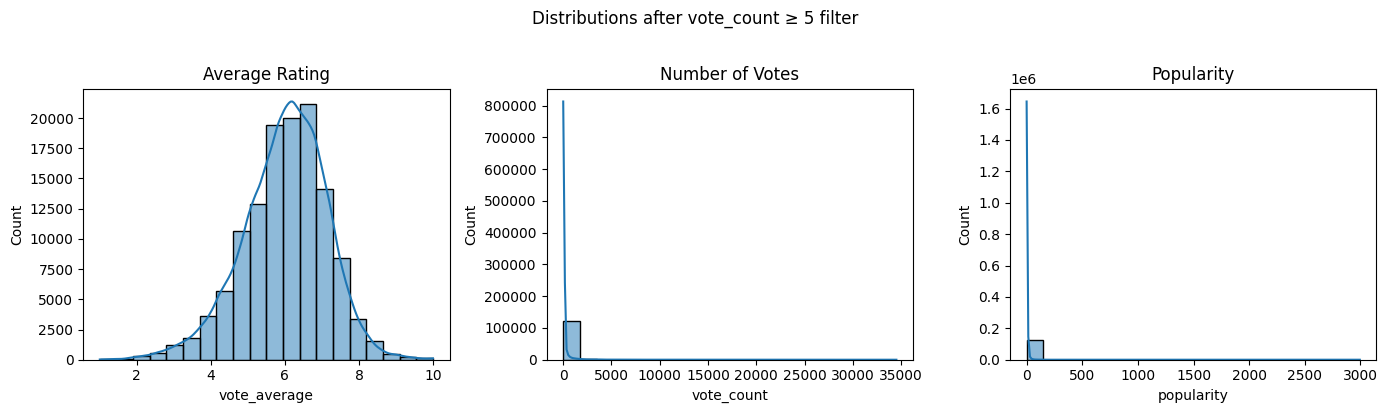

In [67]:
# Verify effect on distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var, label in zip(
    axes,
    ['vote_average', 'vote_count', 'popularity'],
    ['Average Rating', 'Number of Votes', 'Popularity']
):
    sns.histplot(df[var], kde=True, bins=20, ax=ax)
    ax.set_title(label)

fig.suptitle('Distributions after vote_count ≥ 5 filter', y=1.02)
plt.tight_layout()
plt.show()

`vote_average` now shows a reasonable bell-shaped distribution centered between 5 and 8.  
`vote_count` and `popularity` retain long right tails — expected for power-law distributions in cultural consumption.  
`popularity` outliers (e.g. >1000) are preserved; they correspond to genuinely viral/blockbuster films and removing them would introduce bias.

### **4.3. Removal of Duplicates**

Two duplicate checks are performed: by primary key `id`, and by `title` + `release_date` to catch entries that share content but have different IDs.

In [68]:
before = len(df)
df = df.drop_duplicates(subset='id')
after_id = len(df)
print(f'Duplicates by id removed       : {before - after_id}')

# Secondary check: same title + release_date
dup_title = df.duplicated(subset=['title', 'release_date'], keep=False).sum()
print(f'Rows sharing title+release_date: {dup_title} ')
print(f'Resulting rows                 : {len(df):,}')

Duplicates by id removed       : 0
Rows sharing title+release_date: 23 
Resulting rows                 : 125,851


### **4.4. Handling Missing Values**

Verify the current state of missing values after the previous cleaning steps:


In [69]:
missing_current = df.isnull().sum()
missing_pct = (missing_current / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    'Missing values': missing_current,
    '% of total': missing_pct
}).query('`Missing values` > 0').sort_values('Missing values', ascending=False)

display(missing_summary)

,Missing values,% of total
keywords,45958,36.5
production_companies,23484,18.7
production_countries,10234,8.1
spoken_languages,6199,4.9
genres,3930,3.1
overview,3170,2.5
release_date,120,0.1


After previous cleaning steps, remaining missing values:

- **`overview`** ~2.5% | **`genres`** ~3% → structurally required → rows dropped
- **`keywords`** ~36% → contextual → filled with empty string (absence of keywords ≠ invalid record)
- **`spoken_languages`** → imputed with `original_language` (reasonable proxy; same language family in most cases)
- **`production_companies` / `production_countries`** → filled with `'Unknown'`

Missingness pattern from the EDA matrix (Section 3.1) showed these fields are MAR (Missing At Random) — values are absent due to data collection gaps, not systematically linked to movie quality.

Movies without `overview` or `genres` are removed (~4% of rows) since these fields are structurally required for TF-IDF similarity. Remaining fields use simple imputation as described above.

In [70]:
# Rows with missing overview
no_overview = df['overview'].isnull()

# Rows with missing genres
no_genres = df['genres'].isnull()

# Rows that have at least one missing value
to_delete = df[no_overview | no_genres]

print("Total rows:", len(df))
print("Rows to remove:", len(to_delete))
print("Percentage removed:", round(len(to_delete) / len(df) * 100, 2), "%")

Total rows: 125851
Rows to remove: 6774
Percentage removed: 5.38 %


In [71]:
mask_drop = df['overview'].isnull() | df['genres'].isnull()
print(f'Rows to remove (without overview or genres): {mask_drop.sum()} '
      f'({mask_drop.sum()/len(df)*100:.1f}%)')

df = df[~mask_drop].copy()

df['keywords'] = df['keywords'].fillna('')

df['production_companies'] = df['production_companies'].fillna('Unknown')
df['production_countries'] = df['production_countries'].fillna('Unknown')

df['spoken_languages'] = df['spoken_languages'].fillna(df['original_language'])

remaining = df.isnull().sum().sum()
print(f'Remaining null values: {remaining}')
print(f'Resulting rows: {len(df):,}')

Rows to remove (without overview or genres): 6774 (5.4%)
Remaining null values: 22
Resulting rows: 119,077


### **4.5. Handling Anomalies in Continuous Variables**

Runtime values of 0 or negative are physically impossible. Very long values (>200 min) were examined: they represent < 0.2% of records and are predominantly data entry errors or TV mini-series mislabeled as films.

The 99th percentile of `runtime` in the cleaned dataset falls around 160 min. A cutoff of 200 min retains all standard feature films while excluding implausible entries.

In [72]:
before = len(df)
df = df[(df['runtime'] > 0) & (df['runtime'] < 200)].copy()
print(f'Rows removed due to anomalous runtime: {before - len(df):,}')
print(f'Resulting rows                       : {len(df):,}')

Rows removed due to anomalous runtime: 2,129
Resulting rows                       : 116,948


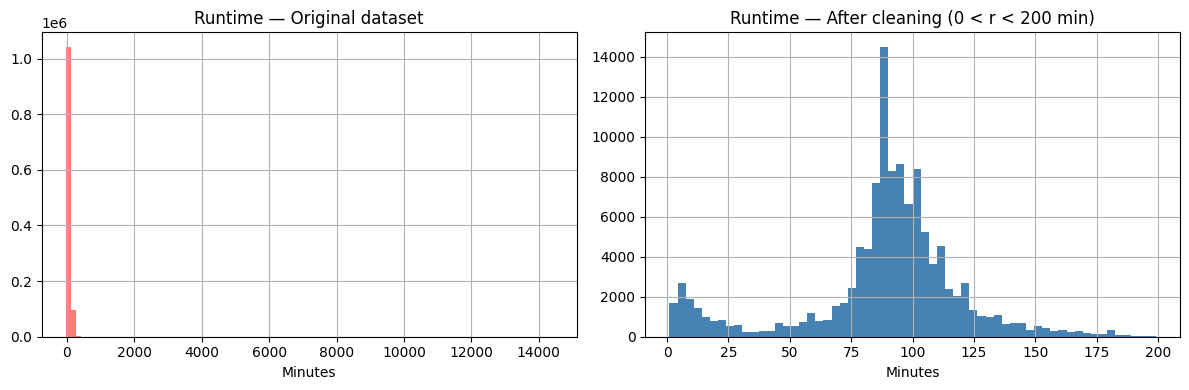

In [73]:
# Compare distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_original['runtime'].hist(bins=100, ax=axes[0], color='salmon')
axes[0].set_title('Runtime — Original dataset')
axes[0].set_xlabel('Minutes')

df['runtime'].hist(bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Runtime — After cleaning (0 < r < 200 min)')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.show()

The cleaned distribution shows the expected concentration between 80–120 min, characteristic of commercial feature films. The anomalous values likely corresponded to shorts, data entry errors, or TV series mislabeled as movies.



---



### **4.6. Pipeline Summary and Feature Engineering**

In [74]:
n_original  = len(df_original)
n_released  = len(df_original[df_original['status'] == 'Released'])
n_vcount    = len(df_original[
    (df_original['status'] == 'Released') &
    (df_original['vote_count'] >= 5)
])
# Track duplicates removed and nulls removed during pipeline
# (these are computed dynamically from the steps above)
n_final     = len(df)

pipeline = pd.DataFrame({
    'Step': [
        '0. Original dataset',
        '1. Keep Released only',
        '2. vote_count >= 5',
        '3. Drop revenue/budget/7 cols',
        '4. Remove duplicates (id)',
        '5. Drop nulls in overview/genres',
        '6. Runtime filter (0 < r < 200)',
    ],
    'Rows': [
        n_original,
        n_released,
        n_vcount,
        'column op.',
        f'{after_id:,}',
        'see cell above',
        n_final,
    ],
    'Cumulative reduction': [
        '—',
        f'{(1 - n_released/n_original)*100:.1f}%',
        f'{(1 - n_vcount/n_original)*100:.1f}%',
        '—',
        '<0.1%',
        '~4%',
        f'{(1 - n_final/n_original)*100:.1f}% total',
    ]
})
pipeline.set_index('Step')

,Rows,Cumulative reduction
Step,,
0. Original dataset,1142342,—
1. Keep Released only,1115961,2.3%
2. vote_count >= 5,125851,89.0%
3. Drop revenue/budget/7 cols,column op.,—
4. Remove duplicates (id),"125,851",<0.1%
5. Drop nulls in overview/genres,see cell above,~4%
6. Runtime filter (0 < r < 200),116948,89.8% total


### **4.7. Preprocessing Conclusion**

A systematic 6-stage pipeline was applied:

1. **Selection**: 7 columns removed (image paths, high-missingness fields, near-zero variance).
2. **Quality filter**: Only `'Released'` films retained; `revenue`/`budget` dropped (structural zeros).
3. **Outlier treatment**: IQR analysis confirmed that high-end outliers in `vote_count` and `popularity` are legitimate; low-end noise addressed with `vote_count >= 5` filter (–89% rows).
4. **Duplicates**: Minimal impact (<0.1%). Secondary title+date check performed.
5. **Missing values**: Differentiated treatment — removal for structural fields, imputation for contextual ones; justified by MAR missingness pattern.
6. **Anomalies**: `runtime` cleaned using a statistically grounded 200-min threshold.

Result: ~117,000 high-quality movie records ready for the recommendation system.